Total images to process: 10
Processing: images (11).jpg
Prediction: 1


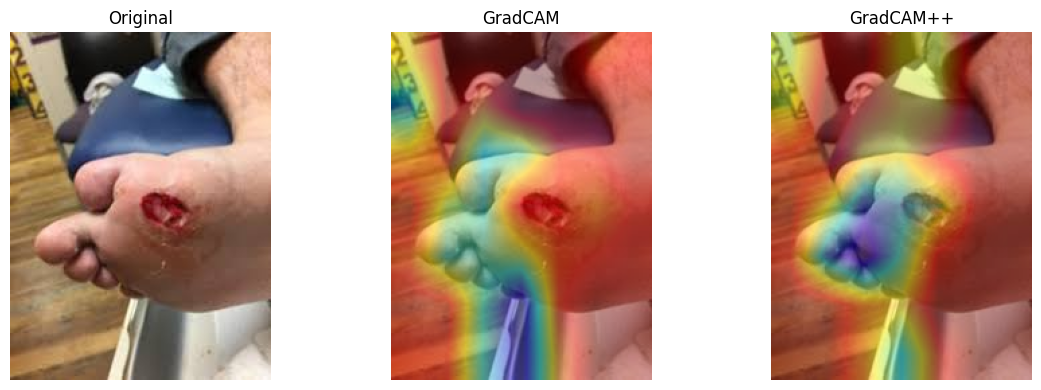

Press Enter for next image or type 'q' to quit:  


Processing: images (1).jpg
Prediction: 0


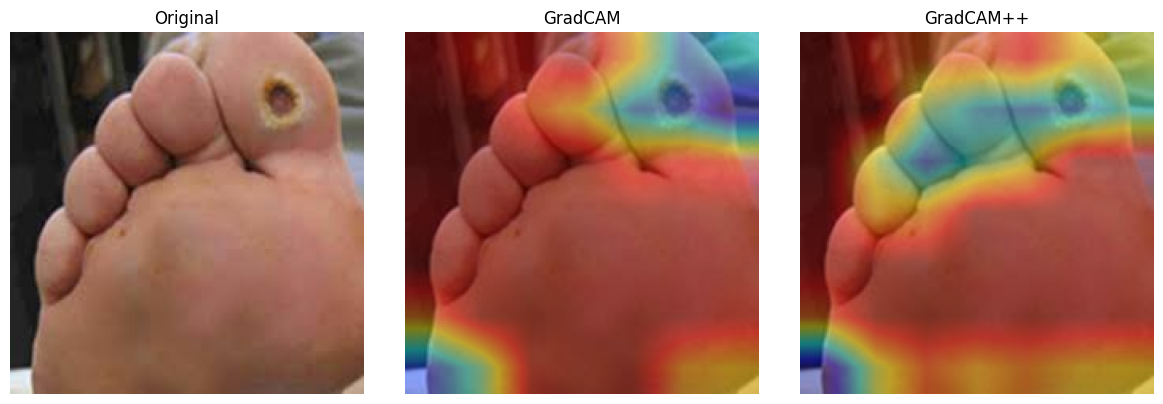

Press Enter for next image or type 'q' to quit:  


Processing: images (7).jpg
Prediction: 1


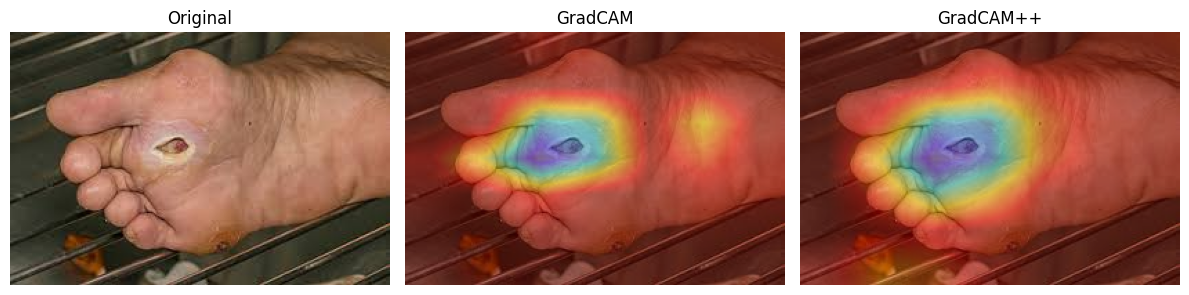

Press Enter for next image or type 'q' to quit:  q


Exiting...


In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus


# -----------------------------
# SETTINGS
# -----------------------------
MAX_IMAGES = 10
RANDOM_SAMPLE = True
SAVE_RESULTS = True
SHOW_IMAGES = True
OUTPUT_DIR = "results"


# -----------------------------
# IMAGE TRANSFORM
# -----------------------------
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# -----------------------------
# LOAD MODEL
# -----------------------------
def load_model(model_path):
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    model.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)
    model.eval()
    return model


# -----------------------------
# PREPROCESS IMAGE
# -----------------------------
def preprocess_image(img):
    return transform(img).unsqueeze(0)


# -----------------------------
# OVERLAY HEATMAP
# -----------------------------
def overlay_heatmap(img, heatmap):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = heatmap * 0.4 + img * 0.6

    return overlay


# -----------------------------
# LOAD TEST IMAGES
# -----------------------------
def load_images(folder):
    image_paths = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".jpg") or file.endswith(".png"):
                image_paths.append(os.path.join(root, file))

    return image_paths


# -----------------------------
# PATHS
# -----------------------------
model_path = r"C:\Users\pc\Downloads\DFU\dfu_model_v1.pth"
image_folder = r"C:\Users\pc\Downloads\DFU\TestSet"


# -----------------------------
# SETUP OUTPUT DIR
# -----------------------------
if SAVE_RESULTS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)


# -----------------------------
# LOAD MODEL
# -----------------------------
model = load_model(model_path)

# Fix ReLU issue for GradCAM
for module in model.modules():
    if isinstance(module, torch.nn.ReLU):
        module.inplace = False

target_layer = model.features[-1]

cam = GradCAM(model=model, target_layers=[target_layer])
cam_plus = GradCAMPlusPlus(model=model, target_layers=[target_layer])


# -----------------------------
# LOAD IMAGES
# -----------------------------
images = load_images(image_folder)

if RANDOM_SAMPLE:
    images = random.sample(images, min(MAX_IMAGES, len(images)))
else:
    images = images[:MAX_IMAGES]

print("Total images to process:", len(images))


# -----------------------------
# PROCESS IMAGES
# -----------------------------
for i, path in enumerate(images):

    print("Processing:", os.path.basename(path))

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    input_tensor = preprocess_image(img)

    output = model(input_tensor)
    pred = torch.argmax(output, dim=1)

    print("Prediction:", pred.item())

    # GradCAM
    heatmap = cam(input_tensor=input_tensor)[0]
    overlay = overlay_heatmap(img, heatmap)

    # GradCAM++
    heatmap_plus = cam_plus(input_tensor=input_tensor)[0]
    overlay_plus = overlay_heatmap(img, heatmap_plus)

    # -----------------------------
    # DISPLAY + SAVE
    # -----------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("GradCAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay_plus.astype(np.uint8))
    plt.title("GradCAM++")
    plt.axis("off")

    plt.tight_layout()

    #  SHOW IMAGE
    if SHOW_IMAGES:
        plt.show()

        user_choice = input("Press Enter for next image or type 'q' to quit: ").lower()
        if user_choice == 'q':
            print("Exiting...")
            break

    
    if SAVE_RESULTS:
        save_path = os.path.join(OUTPUT_DIR, f"result_{i}.png")
        plt.savefig(save_path)

    plt.close()